# Import library

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

import os
import matplotlib.pyplot as plt
import datetime as dt

from tensorflow.keras.layers import Dense, LSTM, Dropout, GRU
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Set Random Seed

In [2]:
random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)


# Global variables

In [3]:
EPOCHS = 100
BATCH_SIZE = 8
WINDOW = 5
HORIZON = 1
TRAIN_SPLIT = 0.8
VAL_SPLIT = 0.5


# Load data

In [4]:
AAPL = pd.read_csv('./Dataset_A/AAPL.csv', parse_dates=True)

AAPL['Date'] = pd.to_datetime(AAPL['Date'])
AAPL.set_index('Date', inplace=True)

# EDA

In [5]:
AAPL.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


<Axes: xlabel='Date'>

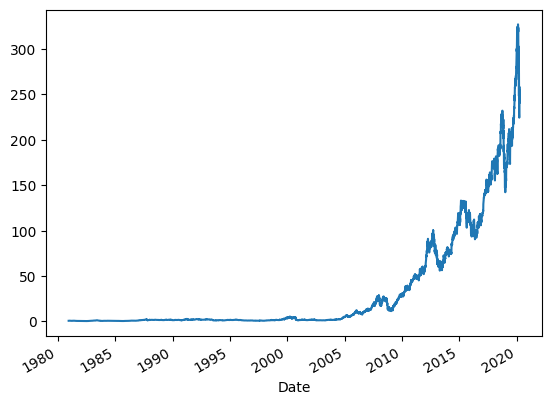

In [6]:
AAPL['Close'].plot()

In [7]:
AAPL['Close'].describe()

count    9909.000000
mean       32.618030
std        58.471899
min         0.196429
25%         1.071429
50%         1.732143
75%        35.761429
max       327.200012
Name: Close, dtype: float64

## Visualize Data as Time Series

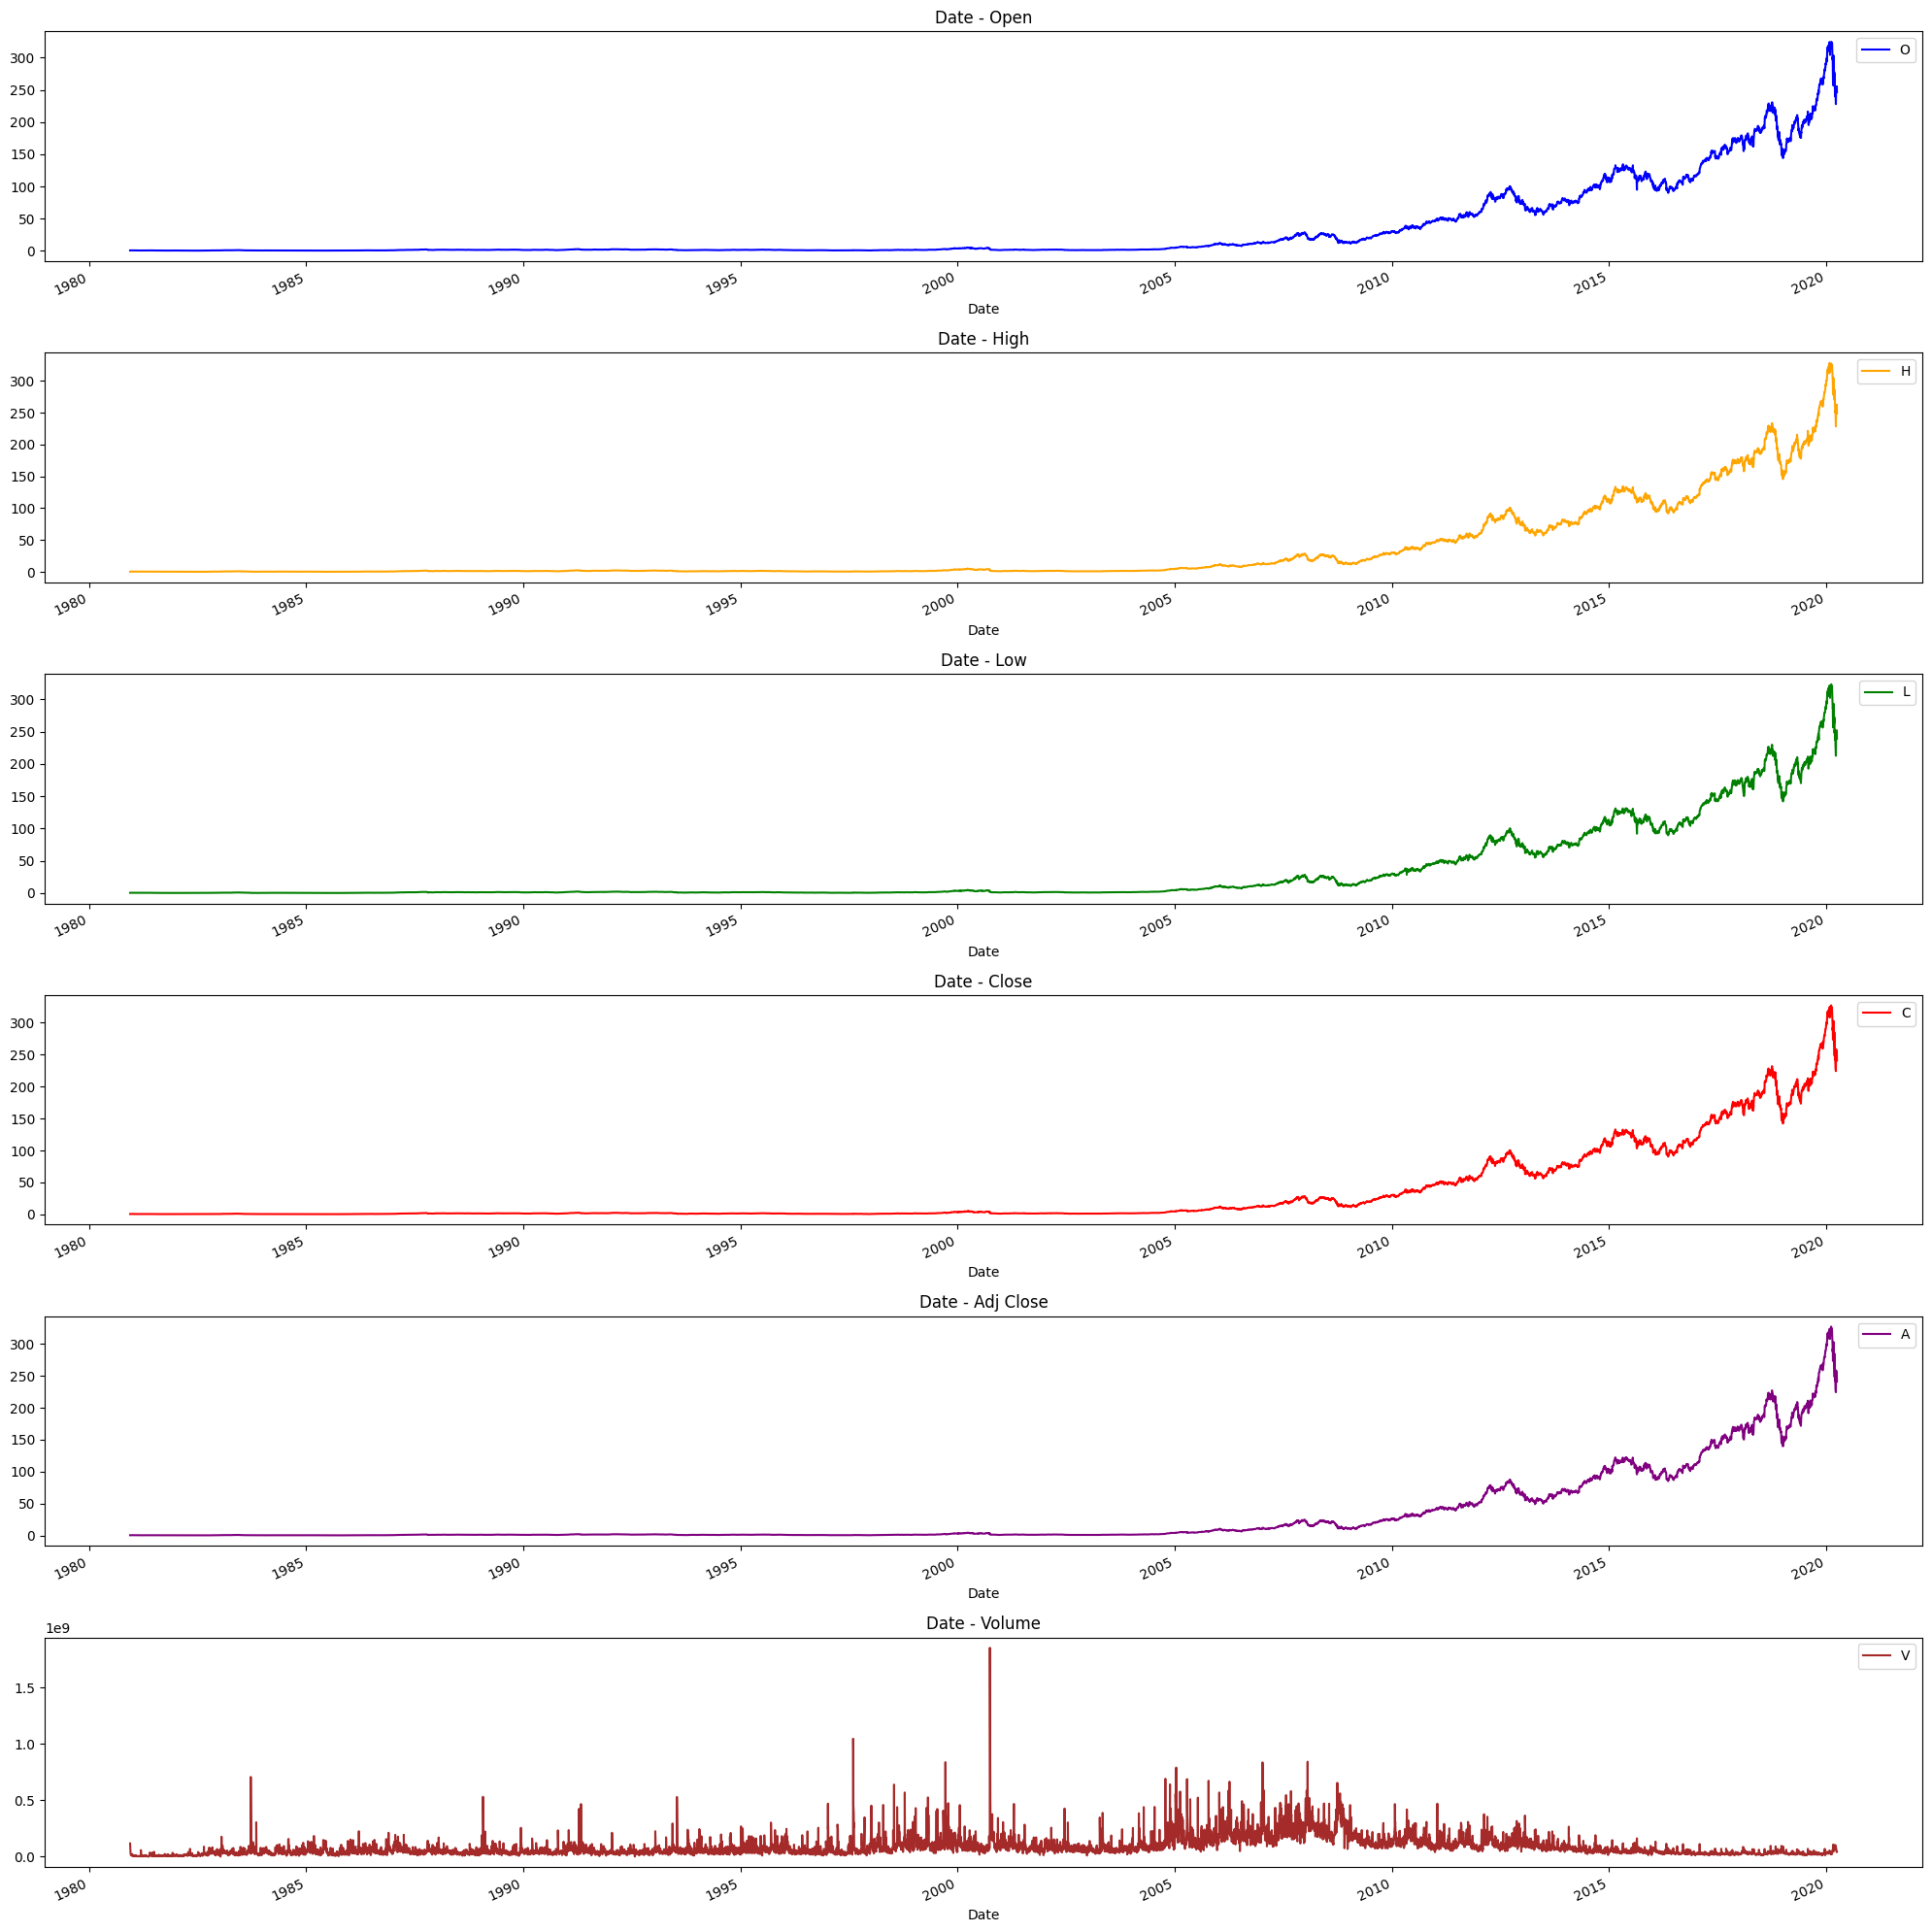

In [8]:
COLORS = ["blue", "orange", "green", "red", "purple", "brown", "pink", "gray", "olive", "cyan"]

def create_vizualizations(data : pd.DataFrame):
    columns = list(data.columns)
    x = data.index
    fig, axes = plt.subplots(nrows=len(columns), ncols=1, figsize=(20, 20), facecolor='w', edgecolor='k')
    for idx, col in enumerate(columns):
        ax = data[col].plot(ax=axes[idx], color=COLORS[idx], title=f'{x.name} - {col}', rot=25)
        ax.legend(col)
    plt.tight_layout()

create_vizualizations(AAPL)

## Missing Values

In [9]:
AAPL.isna().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

# Preprocessing

## Drop Unnecessary Columns

In [10]:
AAPL_close = AAPL.copy()[['Close']]
AAPL_close.head()

,Close
Date,
1980-12-12,0.513393
1980-12-15,0.486607
1980-12-16,0.450893
1980-12-17,0.462054
1980-12-18,0.475446


## Data Normalization

In [11]:
data = AAPL_close.values.tolist()

class normalize:
    def __init__(self, data):
        self.data = np.array(data, dtype='float32')
        self.mean = self.data.mean(axis=0)
        self.std = self.data.std(axis=0)
    
    def __call__(self):
        return list((self.data - self.mean)/self.std)
    
    def inverse(self, data):
        return list(data*self.std + self.mean)

normalizer = normalize(data)

In [12]:
data = normalizer()

## Create TimeSeries Instances

In [13]:
def create_instances(data, window : int = 1, future : int = 1):
    X, y = [], []
    for i in range(len(data)-window-future):
        feature = data[i : i+window]
        # target = data[i+future+1 : i+window+future+1]
        target = data[i+window+future]
        X.append(feature)
        y.append(target)
    return X, y

In [14]:
X, y = create_instances(data, window=WINDOW, future=HORIZON)

## Split Data (Train, Validation, Test)

In [15]:
# Split the data with 80% for training and 10% for validation and 10% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_SPLIT, shuffle=False, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, train_size=VAL_SPLIT, shuffle=False, random_state=42)

## Convert Data to Tensor Slices

In [16]:
# Convert the data to tensors and create dataloaders

X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)

X_val = tf.convert_to_tensor(X_val, dtype=tf.float32)
y_val = tf.convert_to_tensor(y_val, dtype=tf.float32)

X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)

train_data = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH_SIZE)
val_data = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_data = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

# Tuned Model with Learning Rate Scheduler, EMA

We are using GRU instead of LSTM because GRU is a simpler model and it's faster to train so maybe it will be fit more in a small dataset. We are also using a learning rate scheduler to adjust the learning rate during training. This is to prevent the model from getting stuck in a local minima.

## Define Model Architecture

In [17]:
def create_model(time_steps, num_features):
    i = Input(shape=(time_steps, num_features))
    x = LSTM(units=25, activation='relu',)(i)
    x = Dense(1)(x)
    model = Model(inputs=i, outputs=x)
    return model

In [18]:
new_model = create_model(WINDOW, 1)

In [19]:
new_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 5, 1)]            0         
                                                                 
 lstm (LSTM)                 (None, 25)                2700      
                                                                 
 dense (Dense)               (None, 1)                 26        
                                                                 
Total params: 2,726
Trainable params: 2,726
Non-trainable params: 0
_________________________________________________________________


## Define Learning Rate Scheduler

In [20]:
class lr_polynomial_decay:
	def __init__(self, epochs=100, initial_learning_rate=0.01, power=1.0):
		# store the maximum number of epochs, base learning rate,
		# and power of the polynomial
		self.epochs = epochs
		self.initial_learning_rate = initial_learning_rate
		self.power = power

	def __call__(self, epoch):
		# compute the new learning rate based on polynomial decay
		decay = (1 - (epoch / float(self.epochs))) ** self.power
		updated_eta = self.initial_learning_rate * decay
		# return the new learning rate
		return float(updated_eta)

## Compile Model

In [21]:
initial_learning_rate = 0.001

curScheduler = lr_polynomial_decay(initial_learning_rate=initial_learning_rate, epochs=EPOCHS, power=1)

In [22]:
new_model.compile(optimizer=Adam(learning_rate=initial_learning_rate), loss='mae', metrics=[RootMeanSquaredError(), 'mae', MeanAbsolutePercentageError()])

## Train Model

In [23]:
checkpointer = ModelCheckpoint(filepath = './exp/AAPL/weights_best.hdf5', verbose = 1, save_best_only = True)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
lr_schedule = LearningRateScheduler(curScheduler, verbose=1)

his_newModel=new_model.fit(train_data,
                epochs=EPOCHS,
                validation_data=val_data,
                batch_size=BATCH_SIZE,
                callbacks=[checkpointer, early_stopping, lr_schedule])


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/100
989/991 [============================>.] - ETA: 0s - loss: 0.0443 - root_mean_squared_error: 0.1245 - mae: 0.0443 - mean_absolute_percentage_error: 32.7139
Epoch 1: val_loss improved from inf to 0.04752, saving model to ./exp/AAPL\weights_best.hdf5
991/991 [==============================] - 17s 16ms/step - loss: 0.0443 - root_mean_squared_error: 0.1245 - mae: 0.0443 - mean_absolute_percentage_error: 32.6847 - val_loss: 0.0475 - val_root_mean_squared_error: 0.0615 - val_mae: 0.0475 - val_mean_absolute_percentage_error: 4.8088 - lr: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.00099.
Epoch 2/100
991/991 [==============================] - ETA: 0s - loss: 0.0168 - root_mean_squared_error: 0.0556 - mae: 0.0168 - mean_absolute_percentage_error: 8.5396
Epoch 2: val_loss did not improve from 0.04752
991/991 [==============================] - 16s 16ms/step - loss: 0.0168 - root_mean_squared_error: 0

## Evaluate Model

In [24]:
def real_loss(history):
    best_val_loss = min(history.history['val_loss'])
    best_loss = min(history.history['loss'])
    
    best_MAPE = min(history.history['val_mean_absolute_percentage_error'])
    return normalizer.inverse(best_val_loss), normalizer.inverse(best_loss), best_MAPE

print('Best Validation Loss: ', real_loss(his_newModel)[0])
print('Best Training Loss: ', real_loss(his_newModel)[1])
print('Best MAPE: ', real_loss(his_newModel)[2])

Best Validation Loss:  [35.396652]
Best Training Loss:  [33.02039]
Best MAPE:  4.808786869049072


The Model is performing better then the base model based on the validation loss (MAE) and MAPE of 4.8%.

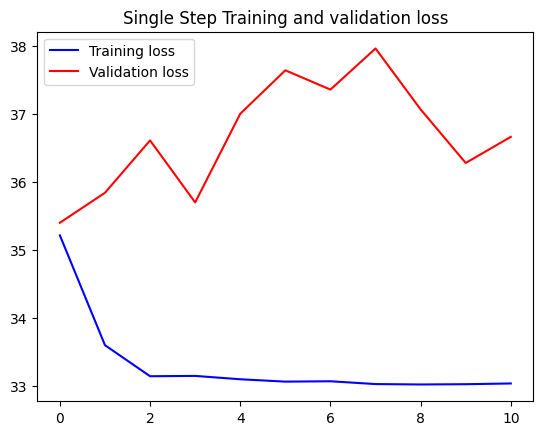

In [25]:
def plot_train_history(history, title):
    loss = normalizer.inverse(history.history['loss'])
    val_loss = normalizer.inverse(history.history['val_loss'])

    epochs = range(len(loss))

    plt.figure()

    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title(title)
    plt.legend()

    plt.show()

plot_train_history(his_newModel, 'Single Step Training and validation loss')

The Model is still overfitting but not as much as the base model

### Model Inference

In [26]:
test_eval = new_model.evaluate(test_data)

print('Test Loss (MAPE): ', normalizer.inverse(test_eval[0]))
print('Test MAPE: ', test_eval[3])

124/124 [==============================] - 1s 5ms/step - loss: 0.0656 - root_mean_squared_error: 0.0933 - mae: 0.0656 - mean_absolute_percentage_error: 2.7524
Test Loss (MAPE):  [36.45074]
Test MAPE:  2.7523648738861084


In [27]:
predictions = new_model.predict(test_data)

124/124 [==============================] - 1s 4ms/step


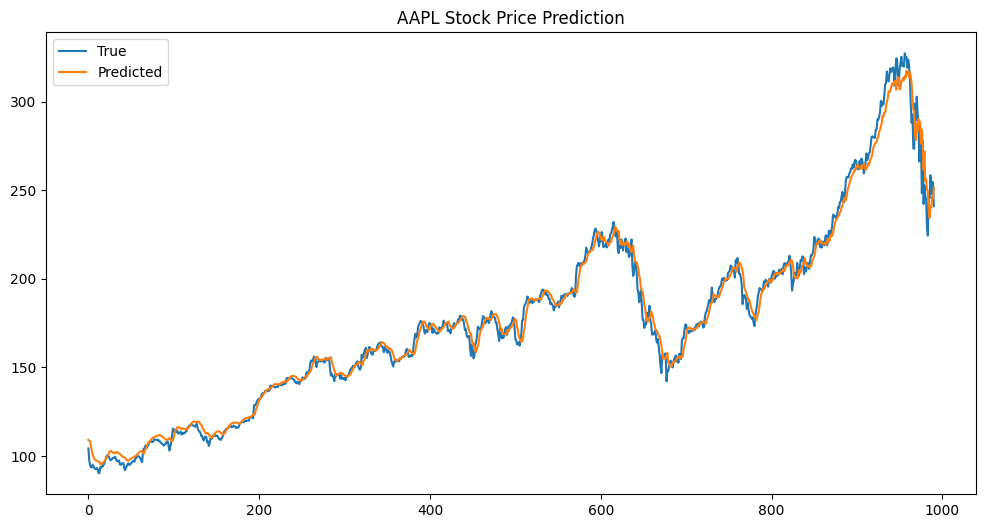

In [28]:
# Plot the predictions
plt.figure(figsize=(12, 6))
plt.plot(normalizer.inverse(y_test), label='True')
plt.plot(normalizer.inverse(predictions), label='Predicted')
plt.title('AAPL Stock Price Prediction')
plt.legend()
plt.show()

# Analysis

The performance of the model is quite good with a MAE of 36.4 on the test data and MAPE of 4.8%. simply the model prediction on the APPLE Stock price test data have a average deviation of $36.4 or 4.8%. Which is quite good for a small dataset. This performance could also be seen from the plot of the model prediction on the test data. The model prediction is quite close to the actual data.

# Conclusion

From the above analysis, we can conclude that the model is performing better than the base model. The model is still overfitting but not as much as the base model. The model can be further improved by using more data and tuning the hyperparameters.